# Computing a grid of mass ratio -> flux for all my companions

Benjamin Pennell

May 6th, 2026

Max Planck Institut für Astronomie, Heidelberg

---

For a particular binary $(M_1, M_2)$, I want to be able to determine what the flux ratio would be.

For a paricular metallicity, take an isochrone. One can simply then look at the corresponding magnitudes for your two objects and convert that magnitude difference to a flux ratio.

In our case, looking at companions to low mass stars, the isochrones only go to $0.1M_\odot$, so we need to extrapolate by fitting a power law to the brown dwarf companions (this works quite well)

In [ ]:
import sys
sys.path.insert(1, '~/AstrometricSignalProcessing/utils')
import style

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
# in new versions of PARSEC they have renamed the Gaia magnitude to G_fSBmag so you may need to swap things out
isochrone_data = pd.read_csv('~/data/PARSEC_logage_6to10_MH_n2p5_0p6_dwarf.csv') # import your isochrones of choice :)

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Step 1: identify the flux ratio at all valid parts on the isochrone

In [2]:
def flux_ratio(m2, m1, mh, isochrone_data, logAge=9):
    # find the isochrone
    mh_closest = min(np.unique(isochrone_data["MH"]), key=lambda x: abs(x - mh))
    df_mh = isochrone_data[(isochrone_data["MH"] == mh_closest) & (isochrone_data["logAge"] == logAge)].copy()
    df_mh_sorted = df_mh.sort_values('Mini')
    mini_available = df_mh_sorted['Mini'].values
    gmag_available = df_mh_sorted['Gmag'].values
    
    # if the companion is too small, return 0, I'll fill it in later with a power law
    if m2 < mini_available.min():
        return 0
    
    # get magnitude for the two masses by interpolating
    interp_gmag = interp1d(mini_available, gmag_available, kind='linear')
    delta_mag = float(interp_gmag(m2)) - float(interp_gmag(m1)) 
    
    # convert to flux ratio
    flux_ratio = 10**(-0.4*delta_mag) 
    return flux_ratio

In [11]:
# Set up the grid
grid_size = np.array([21, 21, 11])
q_range = (0.05, 0.5)
mh_range = (-0.5, 0.5)
qs = np.linspace(*q_range, grid_size[0])
m1s = np.linspace(0.2, 0.4, grid_size[1])
mhs = np.linspace(*mh_range, grid_size[2])
f_grid = np.zeros(grid_size)

# Call flux_ratio() for each element in the grid. tqdm just makes a progress bar
pbar = tqdm(total=grid_size.prod())
for i, q in enumerate(qs):
    for j, m1 in enumerate(m1s):
        for k, mh in enumerate(mhs):
            model_m2 = q * m1
            model_flux_ratio = flux_ratio(model_m2, m1, mh, isochrone_data)
            f_grid[i,j,k] = model_flux_ratio
            pbar.update(1)

  0%|          | 0/4851 [00:00<?, ?it/s]

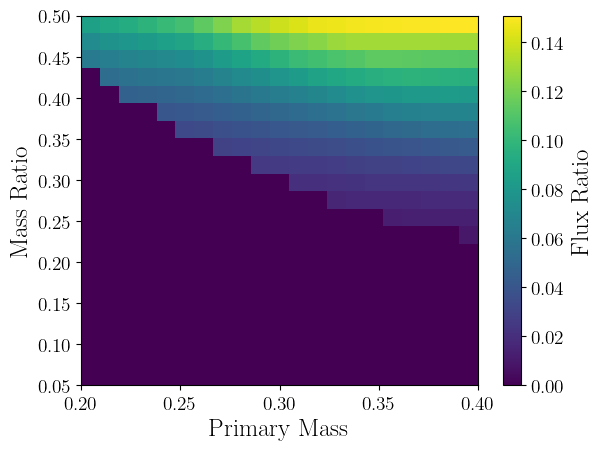

In [12]:
cb = plt.imshow(f_grid[:,:,5], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

There's a bunch of space that the isochrones couldn't do. Fill it in by extrapolating with a power law

### Step 2: fit power laws along mass ratio axes to fill in remaining spots
here's an example. The fit is quite good. Approximately gamma=3.5-4 as one might expect (roughly 3.8 in this case)

In [13]:
def power_law(x, a, b):
    return a * x**b

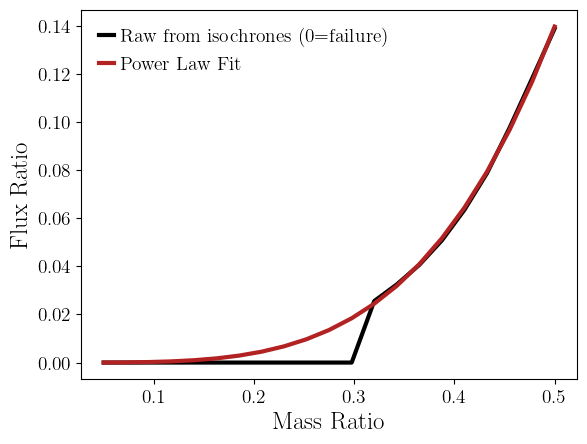

In [ ]:
fs = f_grid[:,10,5]
x, y = qs[fs>0], fs[fs>0]
popt, pcov = curve_fit(power_law, x, y)
plt.plot(qs, fs, lw=3, label="Raw from isochrones (0=failure)");
plt.plot(qs, power_law(qs, *popt), lw=3, label=f"Power Law Fit");
plt.xlabel("Mass Ratio");
plt.ylabel("Flux Ratio");
plt.legend();

In [14]:
gammas = np.zeros((grid_size[1], grid_size[2]))
pbar = tqdm(total=grid_size[1]*grid_size[2])
for j, m1 in enumerate(m1s):
    for k, mh in enumerate(mhs):
        fs = f_grid[:,j,k]
        x, y = qs[fs>0], fs[fs>0]
        if len(x) > 2: # have enough points to actually fit a power law decently
            # we have enough points in almost every column for this to work
            popt, pcov = curve_fit(power_law, x, y)
            f_grid[:,j,k] = power_law(qs, *popt)
            gammas[j,k] = popt[1]
        pbar.update(1)

  0%|          | 0/231 [00:00<?, ?it/s]

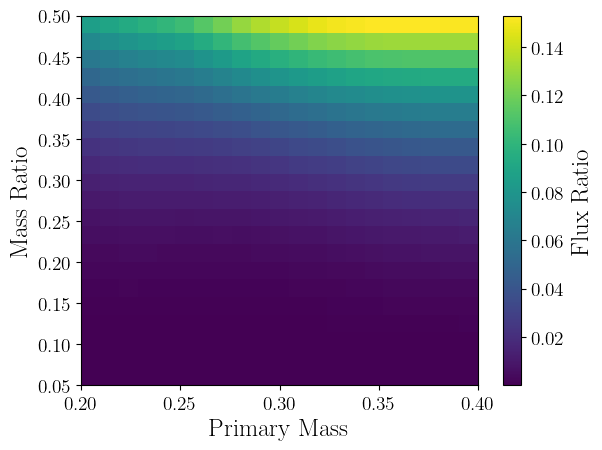

In [15]:
cb = plt.imshow(f_grid[:,:,5], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

Looks lovely. This can be interpolated for any mass/metallicity now.

for interest's sake, we can see what the power law is. It usually sits around 4 but varies considerably. Quite fun.

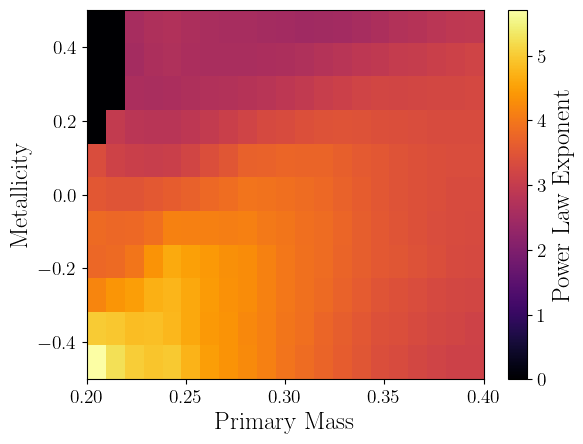

In [120]:
plt.imshow(gammas.T, origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), mhs.min(), mhs.max()], cmap="inferno");
plt.xlabel("Primary Mass");
plt.ylabel("Metallicity");
plt.colorbar(label="Power Law Exponent");